In [2]:
import matplotlib
matplotlib.use("MacOSX")
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy import constants
from math import *
from pylab import *
from scipy.signal import find_peaks

In [3]:
c = constants.c

EXAMPLE SPECTRUM - Generates a gaussian spectrum for testing code

In [4]:
def generate_measured_spectrum(lambda0, fwhm_lambda, num_points=2000):

    sigma_lambda = fwhm_lambda / (2 * np.sqrt(2 * np.log(2)))

    lambda_vals = np.linspace(lambda0 - 3*sigma_lambda,
                              lambda0 + 3*sigma_lambda,
                              num_points)

    amp_lambda = np.exp(-(lambda_vals - lambda0)**2 / (2 * sigma_lambda**2))

    freq_vals = c / lambda_vals

    # idx = np.argsort(freq_vals)
    # spectrum = np.column_stack((freq_vals[idx], amp_lambda[idx]))
    
    spectrum = np.column_stack((lambda_vals, amp_lambda))

    return spectrum

In [76]:
class LaserPulse:
    """
    Laser pulse reconstructed from measured spectrum.
    """

    def __init__(self,
                 spectrum,
                 N=2**19,
                 threshold=0.01,
                 dt=0.05e-15,
                 absolute_phase=0.0,
                 group_delay=0.0e-15,
                 group_delay_dispersion=0.0,
                 third_order_dispersion=0.0):

        # ----------------------------------------------------
        # Basic parameters
        # ----------------------------------------------------
        self.spectrum = spectrum
        self.N = N
        self.threshold = threshold
        self.dt = dt
        self.abosolute_phase = absolute_phase
        self.group_delay = group_delay
        self.group_delay_dispersion = group_delay_dispersion
        self.third_order_dispersion = third_order_dispersion
        self.fs = 1 / dt

        spectrum_lambda = spectrum[np.argsort(spectrum[:, 0])]
        freq_data = c / spectrum_lambda[:, 0]
        amp_data = spectrum_lambda[:, 1]
        idx = np.argsort(freq_data)
        spectrum = np.column_stack((freq_data[idx], amp_data[idx]))

        self.freq_data = spectrum[:, 0]
        self.amp_data = spectrum[:, 1]

        # ----------------------------------------------------
        # Background subtraction + thresholding
        # ----------------------------------------------------

        n = spectrum.shape[0]

        background = np.hstack((self.amp_data[:int(0.01 * n)],
                                self.amp_data[-int(0.01 * n):])).mean()

        self.amp_data -= background

        max_amp = np.max(self.amp_data)

        valid_idx = self.amp_data >= threshold * max_amp

        self.freq_valid = self.freq_data[valid_idx]
        self.amp_valid = self.amp_data[valid_idx]

        # ----------------------------------------------------
        # Pulse spectral properties
        # ----------------------------------------------------

        self.central_frequency = np.mean(self.freq_valid)

        self.bandwidth = self.freq_valid.max() - self.freq_valid.min()

        self.bandwidth *= 3

        # ----------------------------------------------------
        # FFT frequency bins
        # ----------------------------------------------------

        self.f_bins = np.fft.fftfreq(self.N, d=self.dt)

        # ----------------------------------------------------
        # Interpolate measured spectrum
        # onto FFT bins
        # ----------------------------------------------------

        self.E_f = np.interp(self.f_bins,
                             self.freq_valid,
                             self.amp_valid,
                             left=0,
                             right=0)

        self.E_f = self.E_f.astype(complex)

        # ----------------------------------------------------
        # Spectral phase
        # ----------------------------------------------------

        phi_0 = absolute_phase

        phi_1 = group_delay * 2 * np.pi

        phi_2 = group_delay_dispersion * (2 * np.pi)**2

        phi_3 = third_order_dispersion * (2 * np.pi)**3
        
        self.spectral_phase = (phi_0
                            + phi_1 * self.f_bins
                            + 0.5 * phi_2 * self.f_bins**2
                            + (1.0 / 6.0) * phi_3 * self.f_bins**3)

        self.E_f *= np.exp(1j * self.spectral_phase)

        # self.E_f = 0.5 * (self.E_f + np.conj(self.E_f[::-1])) #Hermition symmetry

    def plot_spectrum(self):

        plt.figure(figsize=(12, 4))

        plt.scatter(self.f_bins, np.abs(self.E_f), s=0.5)

        plt.xlabel("Frequency / Hz")
        plt.ylabel("Amplitude (arb. units)")
        # plt.xlim(3.25e14, 4.25e14)
        plt.xlim(2.5e14, 5.5e14)
        plt.title("Pulse spectrum")

        plt.grid(True)
        plt.savefig("Spectrum.png")
        plt.show()

        return self.f_bins, self.E_f

    def field(self):

        ### Computes the inverse FFT to get the time-domain field
        ### returns the time array and the electric field in the time domain
        
        self.E_t = np.fft.ifft(self.E_f)

        self.t = np.arange(self.N) * self.dt
        self.t_shift = (np.arange(self.N) - self.N // 2) * self.dt

        self.E_t_shift = np.fft.fftshift(self.E_t)
        self.E_f_shift = np.fft.fftshift(self.E_f)

        # Shift the time-domain field so that the peak is centered at t=0, this may not be the case if we add GDD
        peak_idx = np.argmax(np.abs(self.E_t_shift))
        shift = self.N // 2 - peak_idx
        self.E_t_shift = np.roll(self.E_t_shift, shift)

        return self.t_shift, self.E_t_shift
    
    def plot_field(self, time_window=100e-15):

        t, E = self.field()

        plt.figure(figsize=(10, 6))

        plt.plot(t * 1e15,
                np.real(E) / np.max(np.abs(np.real(E))))

        plt.xlabel("Time (fs)")
        plt.ylabel("Electric field")
        plt.xlim(-time_window * 1e15, time_window * 1e15)
        plt.grid(True)

        plt.savefig("Field.png")
        plt.show()
    
    def autocorrelate(self, max_delay):

        t, E = self.field()
        
        
        #set integration limits to 3x max delay to ensure we capture the full autocorrelation signal
        int_mask = (t >= -8*max_delay) & (t <= 8*max_delay)

        t = t[int_mask]
        E = E[int_mask]
        
        signal = []
        delays = np.linspace(-max_delay, max_delay, 1000)

        for d in delays:
            # shift field using interpolation (safe for non-integer shifts)
            E_delayed = np.interp(t - d, t, E, left=0, right=0)
            
            I = np.abs(E + E_delayed)**4   # intensity of SHG
            integration = np.trapezoid(I, t) # integrate over time to get autocorrelation signal at this delay
            signal.append(integration)

        signal = np.array(signal)
        signal /= signal[0]
        signal -= 1.0

        plt.plot(delays * 1e15, signal)
        plt.xlabel("Delay (fs)")
        plt.ylabel("Autocorrelation Signal")
        plt.title("Interferometric Autocorrelation")
        plt.grid(True)
        plt.show()

        return delays, signal

Example Spectrum

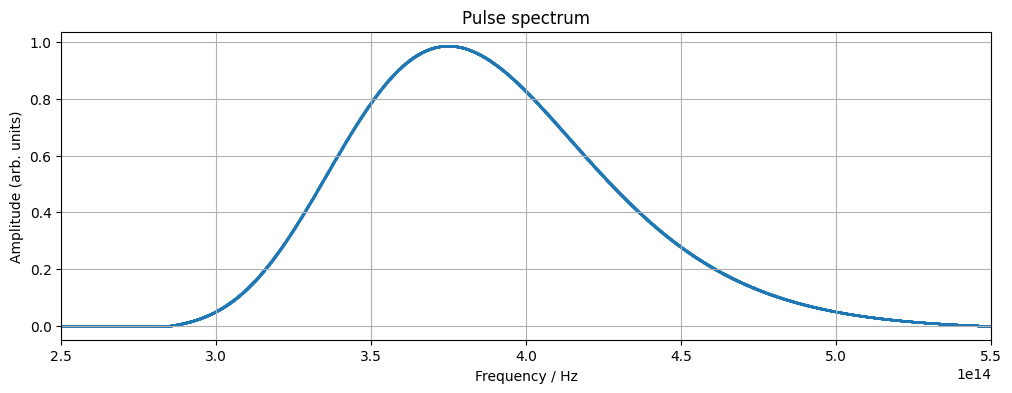

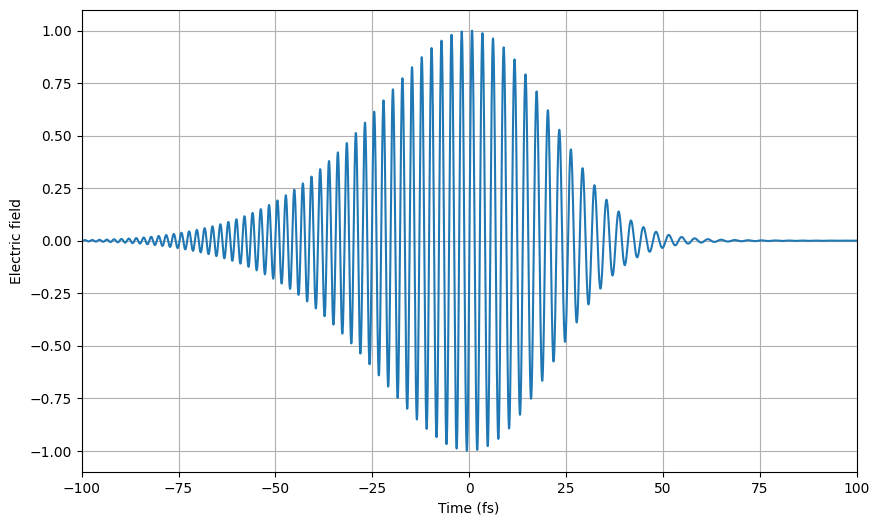

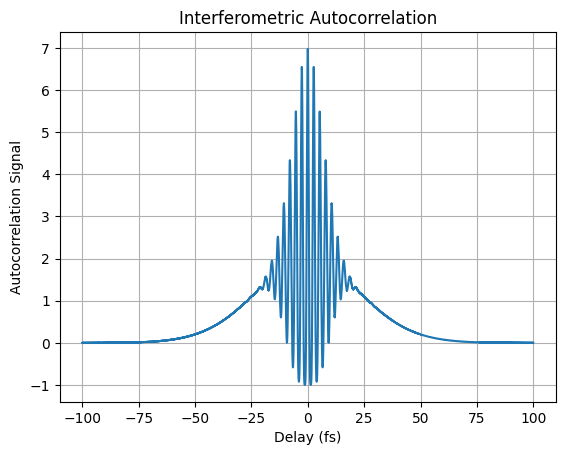

In [ ]:
lambda0 = 800e-9
fwhm_lambda = 200e-9

THRESHOLD = 0.0

spectrum = generate_measured_spectrum(lambda0, fwhm_lambda)

pulse = LaserPulse(spectrum=spectrum,
                   N=2**19,
                   threshold=THRESHOLD,
                   dt=0.05e-15,
                   absolute_phase=np.pi,
                   group_delay=0.0e-15,
                   group_delay_dispersion=90.0e-30,
                   third_order_dispersion=0.0)
pulse.plot_spectrum()
pulse.plot_field(time_window=100e-15)
delay, signal = pulse.autocorrelate(max_delay=100e-15)

Real measured spectrum

In [13]:
chimera_spectrum = np.genfromtxt("spectra/2026jun01_osc_spectrum.csv",
                         delimiter=",",
                         skip_header=17,
                         skip_footer=1)
chimera_spectrum[:, 0] *= 1e-9 # convert from nm to m

In [73]:
trans_limit = LaserPulse(spectrum=chimera_spectrum)
freq, amp = trans_limit.plot_spectrum()
t, E = trans_limit.field()
trans_limit.plot_field(time_window=200e-15)
delay, signal = trans_limit.autocorrelate(max_delay=100e-15)
# trans_limit.test(50e-15)

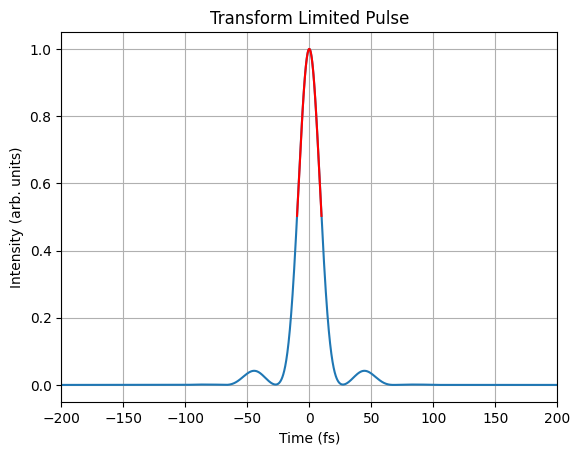

FWHM of transform limited pulse: 19.70 fs


In [11]:
I = np.abs(E)**2
I /= np.max(I)

indices = np.argwhere(I > 0.5 * I.max()) # find peaks above 50% of max signal
FWHM = t[indices[-1]] - t[indices[0]]

plt.plot(t * 1e15, I)
plt.plot(t[indices] * 1e15, I[indices], c='r')
plt.xlabel("Time (fs)")
plt.ylabel("Intensity (arb. units)")
plt.xlim(-200, 200)
plt.title("Transform Limited Pulse")
plt.grid(True)
plt.show()

print(f"FWHM of transform limited pulse: {FWHM[0] * 1e15:.2f} fs")


In [ ]:
chimera_pulse = LaserPulse(spectrum=chimera_spectrum, group_delay_dispersion=500.0e-30, third_order_dispersion=0.0e-45)
freq, amp = chimera_pulse.plot_spectrum()
chimera_pulse.plot_field(time_window=200e-15)
delay, signal = chimera_pulse.autocorrelate(max_delay=150e-15)
# test(chimera_pulse, 50e-15)

: 

In [55]:
def read_AC_data(filename):
    # reads measured autocorrelation data from CSV file and converts stage position to delay, then plots the autocorrelation signal vs delay
    AC_data = np.genfromtxt(filename, delimiter=",", skip_header=1)

    n = len(AC_data)

    #convert stage position to delay
    delay = AC_data[:, 0] * 2e-3 / c
    voltage = AC_data[:, 1]

    background = np.hstack((voltage[:int(0.01 * n)],
                            voltage[-int(0.01 * n):])).mean()
    voltage -= background
    voltage *= 7 / voltage.max() # scale so that max signal is 8x background, as expected for interferometric autocorrelation of a transform-limited pulse
    # voltage += 1 # shift so that background is at 1, as expected for interferometric autocorrelation

    delay -= delay[np.argmax(voltage)] # shift delays so that peak is at zero delay

    plt.plot(delay * 1e15, voltage)
    plt.xlabel("Delay (fs)")
    plt.ylabel("Autocorrelation Signal (arb. units)")
    plt.title("Measured Autocorrelation")
    plt.grid(True)
    plt.savefig("Measured_AC.png")
    plt.show()

    return delay, voltage

delay_data, voltage_data = read_AC_data('/Users/liam/Imperial/Chimera/Oscillator_AC/AC/2026June04_AC3.csv')

In [50]:
def load_AC_data(filename):
    AC_data = np.genfromtxt(filename, delimiter=",", skip_header=1)

    n = len(AC_data)

    # Convert stage position to delay
    delay = AC_data[:, 0] * 2e-3 / c
    voltage = AC_data[:, 1]

    background = np.hstack((
        voltage[:int(0.01 * n)],
        voltage[-int(0.01 * n):]
    )).mean()

    voltage -= background
    voltage *= 7 / voltage.max()

    # Shift peak to zero delay
    delay -= delay[np.argmax(voltage)]

    return delay, voltage

def plot_two_AC_data(file1, file2):
    delay1, voltage1 = load_AC_data(file1)
    delay2, voltage2 = load_AC_data(file2)

    plt.figure(figsize=(8, 5))
    plt.plot(delay1 * 1e15, voltage1, label="AC3")
    plt.plot(delay2 * 1e15, voltage2, label="AC1")

    plt.xlabel("Delay (fs)")
    plt.ylabel("Autocorrelation Signal (arb. units)")
    plt.title("Measured Autorrelations")
    plt.grid(True)
    plt.legend()

    plt.savefig("Measured_AC_comparison.png")
    plt.show()

    return (delay1, voltage1), (delay2, voltage2)

plot_two_AC_data(
    "/Users/liam/Imperial/Chimera/Oscillator_AC/AC/2026June04_AC3.csv",
    "/Users/liam/Imperial/Chimera/Oscillator_AC/AC/2026June03_AC1.csv"
)

((array([-1.37528476e-13, -1.37585182e-13, -1.37418400e-13, ...,
          1.29239409e-13,  1.29276101e-13,  1.29392848e-13]),
  array([-0.00393099, -0.00188344,  0.00512788, ...,  0.00084663,
          0.01021573, -0.00250391])),
 (array([-9.95888963e-14, -9.95588755e-14, -9.95622111e-14, ...,
          1.67152304e-13,  1.67262380e-13,  1.67255709e-13]),
  array([ 0.10041099,  0.10264595,  0.09622045, ..., -0.15521212,
         -0.15493275, -0.13565625])))

In [54]:
def plot_two_AC_stacked(file1, file2):
    delay1, voltage1 = load_AC_data(file1)
    delay2, voltage2 = load_AC_data(file2)

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(8, 8),
        sharex=True
    )

    ax1.plot(delay1 * 1e15, voltage1)
    ax1.set_ylabel("Signal (arb. units)")
    ax1.set_title("AC3")
    ax1.grid(True)

    ax2.plot(delay2 * 1e15, voltage2)
    ax2.set_xlabel("Delay (fs)")
    ax2.set_ylabel("Signal (arb. units)")
    ax2.set_title("AC1")
    ax2.grid(True)

    fig.suptitle("Measured Autocorrelations")
    fig.tight_layout()

    plt.savefig("Measured_AC_stacked.png")
    plt.show()

    return (delay1, voltage1), (delay2, voltage2)

plot_two_AC_stacked(
    "/Users/liam/Imperial/Chimera/Oscillator_AC/AC/2026June04_AC3.csv",
    "/Users/liam/Imperial/Chimera/Oscillator_AC/AC/2026June04_AC6.csv"
)

((array([-1.37528476e-13, -1.37585182e-13, -1.37418400e-13, ...,
          1.29239409e-13,  1.29276101e-13,  1.29392848e-13]),
  array([-0.00393099, -0.00188344,  0.00512788, ...,  0.00084663,
          0.01021573, -0.00250391])),
 (array([-1.40890803e-13, -1.40900809e-13, -1.40790733e-13, ...,
          1.25883754e-13,  1.25823712e-13,  1.25923782e-13]),
  array([-0.04926888, -0.04831884, -0.03786844, ...,  0.0314842 ,
          0.04288464,  0.02768406])))

In [34]:
from scipy.signal import find_peaks
from scipy.interpolate import CubicSpline

peaks, properties = find_peaks(
    voltage_data,
    prominence=0.4,
    distance=50
)
delay_peaks = delay_data[peaks]
voltage_peaks = voltage_data[peaks]

envelope = CubicSpline(delay_peaks, voltage_peaks)
delay_smooth = np.linspace(delay_data.min(), delay_data.max(), 10000)
envelope_smooth = np.interp(delay_smooth, delay_peaks, voltage_peaks)

indices = np.argwhere(envelope_smooth > 0.5 * envelope_smooth.max()) # find peaks above 50% of max signal
FWHM = delay_smooth[indices[-1]] - delay_smooth[indices[0]]
print(f"FWHM of measured pulse: {FWHM[0] * 1e15:.2f} fs")

plt.figure(figsize=(10,6))

plt.plot(delay_data * 1e15,
         voltage_data,
         alpha=0.5,
         label="Measured AC")

plt.plot(delay_peaks * 1e15,
         voltage_peaks,
         "x",
         label="Detected peaks")

plt.plot(delay_smooth * 1e15,
         envelope_smooth,
         linewidth=2,
         label="Envelope")

plt.plot(delay_smooth[indices] * 1e15,
         envelope_smooth[indices],
         "o",
         label="FWHM points")

plt.xlabel("Delay (fs)")
plt.ylabel("Signal")
plt.grid(True)
plt.legend()

plt.show()

FWHM of measured pulse: 30.92 fs


In [39]:
plt.plot(delay * 1e15, signal, label='simulation')
plt.plot(delay_data * 1e15, voltage_data, label='data')
plt.legend()
plt.xlabel("Delay (fs)")
plt.ylabel("Autocorrelation Signal (arb. units)")
plt.title("Measured Autocorrelation")
plt.grid(True)
plt.savefig("Measured_AC.png")
plt.show()

FWHM of transform limited pulse autocorrelation:  [34.29342934] fs


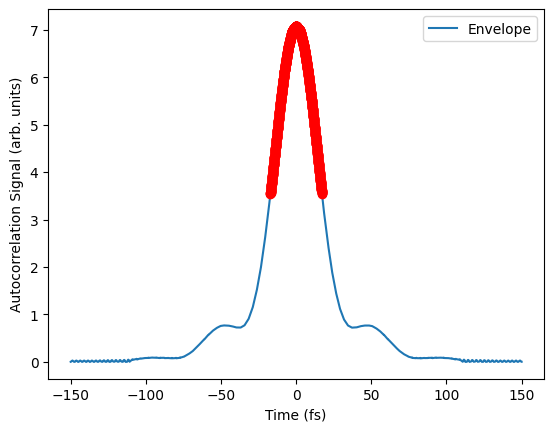

In [88]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
peaks, _ = find_peaks(signal, height=0)
time_peaks = delay[peaks]


envelope = np.interp(delay, time_peaks, signal[peaks])
indices = np.argwhere(envelope > 0.5 * envelope.max()) # find peaks above 50% of max signal
FWHM = delay[indices[-1]] - delay[indices[0]]
print("FWHM of transform limited pulse autocorrelation: ", FWHM * 1e15, "fs")
plt.plot(delay * 1e15, envelope, label='Envelope')
plt.plot(delay[indices] * 1e15, envelope[indices], 'ro')
plt.xlabel("Time (fs)")
plt.ylabel("Autocorrelation Signal (arb. units)")
plt.legend()
plt.show()